This is a copy of the uproot-based analysis used for the H->gamgam for the ATLAS open data files, but applied to the DELPHES output root file for the 10,000 gg->H->gamgam events generated with MadGraph -> Pythia8 -> DELPHES

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak
import time
import atlasopenmagic as atom
import vector as v
import math
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel
from scipy.special import erf
from lmfit import Model

In [12]:
file = '/Users/chris/intro-hep-project/MG5_aMC_v3_5_3/Delphes/day5_detector_output.root'
tree = uproot.open(file+':Delphes;1')
print(len(tree.keys()))
print(tree.keys())
for key in tree.keys(): print(key)

variables = ["Photon.PT","Photon.Eta","Photon.Phi","Photon.E",'Photon_size']

406
['Event', 'Event/Event.fUniqueID', 'Event/Event.fBits', 'Event/Event.Number', 'Event/Event.ReadTime', 'Event/Event.ProcTime', 'Event/Event.ProcessID', 'Event/Event.MPI', 'Event/Event.Weight', 'Event/Event.CrossSection', 'Event/Event.CrossSectionError', 'Event/Event.Scale', 'Event/Event.AlphaQED', 'Event/Event.AlphaQCD', 'Event/Event.ID1', 'Event/Event.ID2', 'Event/Event.X1', 'Event/Event.X2', 'Event/Event.ScalePDF', 'Event/Event.PDF1', 'Event/Event.PDF2', 'Event_size', 'Weight', 'Weight/Weight.fUniqueID', 'Weight/Weight.fBits', 'Weight/Weight.Weight', 'Weight_size', 'Particle', 'Particle/Particle.fUniqueID', 'Particle/Particle.fBits', 'Particle/Particle.PID', 'Particle/Particle.Status', 'Particle/Particle.IsPU', 'Particle/Particle.M1', 'Particle/Particle.M2', 'Particle/Particle.D1', 'Particle/Particle.D2', 'Particle/Particle.Charge', 'Particle/Particle.Mass', 'Particle/Particle.E', 'Particle/Particle.Px', 'Particle/Particle.Py', 'Particle/Particle.Pz', 'Particle/Particle.P', 'Parti

In [95]:
# note that [:,0] corresponds to first photon for all events
# don't use ID cut because truth level photons in Delphes output already have id+iso criteria met

def cut_diphoton(photon_size):
    return (photon_size == 2)

def cut_pt(photon_pt):
    g1ptpass = photon_pt[:,0] > 50
    g2ptpass = photon_pt[:,1] > 30
    return (g1ptpass & g2ptpass)

# 1.37 < |η| < 1.52 region cut
def cut_transition(photon_eta):
    g1cut = (np.abs(photon_eta[:,0]) > 1.52) | (np.abs(photon_eta[:,0]) < 1.37)
    g2cut = (np.abs(photon_eta[:,1]) > 1.52) | (np.abs(photon_eta[:,1]) < 1.37)
    return (g1cut & g2cut)

# this function same as in HZZ
def calc_mass(pt,eta,phi,E):
    # first create a 4vec for each of the particles
    p4 = v.zip({"pt":pt,"eta":eta,"phi":phi,"e":E})
    p4_sum = p4[:,0] + p4[:,1]
    M = p4_sum.M
    return M

def calc_digam_pt(pt,eta,phi,E):
    p4 = v.zip({"pt":pt,"eta":eta,"phi":phi,"e":E})
    p4_sum = p4[:,0] + p4[:,1]
    return p4_sum.pt

# discard events with diphoton mass = 0 
def cut_mass(M):
    return (M != 0)

# make pt/M cut
# pT relative to invariant mass threshold: $p_T/m_{\gamma\gamma} > 0.35$ 
# keeps photons symmetric and energetic relative to system
def cut_ptvsm(photon_pt,M):
    return (photon_pt[:,0]/M > 0.35) & (photon_pt[:,1]/M > 0.35)

def getdphi(photon_phi):
    phi1 = photon_phi[:,0]
    phi2 = photon_phi[:,1]
    dphi = np.abs(phi1-phi2)
    for d in dphi:
        if d > np.pi: d = 2*np.pi - d
    return dphi


In [97]:
print("Examining sim file: "+str(file))

masses_all = []
pts_lead   = []
pts_sub    = []
dphis      = []
etas       = []
pts_digam  = []

for data in tree.iterate(variables,library='ak'):
    print("Num events before cuts: "+str(len(data)))

    print("Num photons per event: " + str(data['Photon_size']))
    data = data[cut_diphoton(data['Photon_size'])]
    print("Num events after diphoton req: "+str(len(data)))
    #print(data['Photon.PT'])

    data = data[cut_pt(data['Photon.PT'])]
    print("Num events after pT cuts: "+str(len(data)))

    data = data[cut_transition(data['Photon.Eta'])]
    print("Num events after transition region cuts: "+str(len(data)))
    
    mass = calc_mass(data['Photon.PT'],data['Photon.Eta'],data['Photon.Phi'],data['Photon.E'])

    data = data[cut_mass(mass)]
    print("Num events after null diphoton mass cuts: "+str(len(data)))

    data = data[cut_ptvsm(data['Photon.PT'],mass)]
    print("Num events after photon pT vs mass cuts: "+str(len(data)))

    masses_all.append(mass)

    pts_lead.append(data['Photon.PT'][:,0]) # leading photon pt
    pts_sub.append(data['Photon.PT'][:,1]) # leading photon pt
    etas.extend([data['Photon.Eta'][:,1],data['Photon.Eta'][:,0]])
    dphis.append(getdphi(data['Photon.Phi']))
    pts_digam.append(calc_digam_pt(data['Photon.PT'],data['Photon.Eta'],data['Photon.Phi'],data['Photon.E']))

masses_all = ak.concatenate(masses_all)
pts_lead   = ak.concatenate(pts_lead)
pts_sub    = ak.concatenate(pts_sub)
dphis      = ak.concatenate(dphis)
etas       = ak.concatenate(etas)
pts_digam   = ak.concatenate(pts_digam)


Examining sim file: /Users/chris/intro-hep-project/MG5_aMC_v3_5_3/Delphes/day5_detector_output.root
Num events before cuts: 10000
Num photons per event: [0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, ..., 0, 1, 1, 0, 2, 2, 2, 1, 2, 1, 2, 1]
Num events after diphoton req: 4884
Num events after pT cuts: 3995
Num events after transition region cuts: 3587
Num events after null diphoton mass cuts: 3587
Num events after photon pT vs mass cuts: 2776


Text(117, 840, '$\\sigma$:     1.1196 $\\pm$ 0.0125')

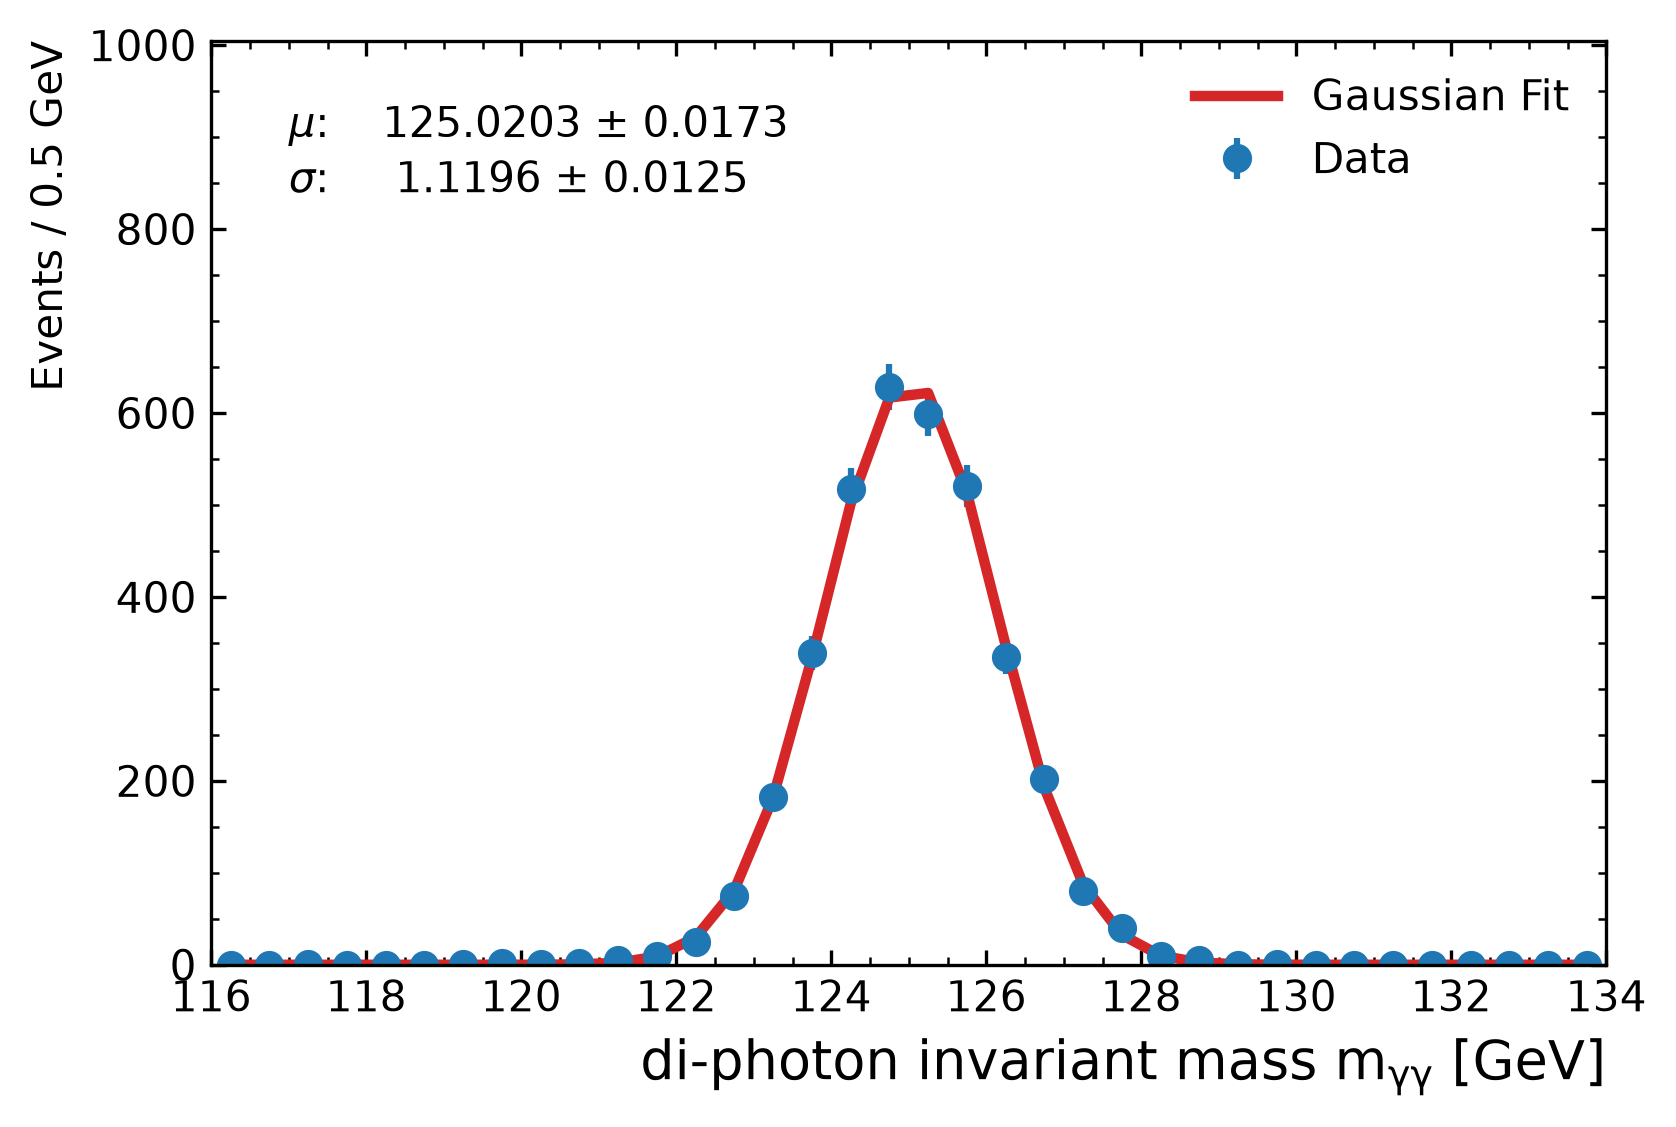

In [49]:
fit_color = '#d62728'  

# x-axis range of the plot
xmin = 116 #GeV
xmax = 134 #GeV

# Histogram bin setup
step_size = 0.5 #GeV
bins = np.arange(start=xmin, # The interval includes this value
                    stop=xmax+step_size, # The interval doesn't include this value
                    step=step_size ) # Spacing between values
bincenters = np.arange(start=xmin+step_size/2, # The interval includes this value
                        stop=xmax+step_size/2, # The interval doesn't include this value
                        step=step_size ) # Spacing between values

# Creating histogram from data
data_x,_ = np.histogram(ak.to_numpy(masses_all),
                        bins=bins) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data

# do the gaussian fit
gauss_fit = GaussianModel()
pars = gauss_fit.guess(data_x,x=bincenters,amplitude=100,center=125,sigma=2)

fit = gauss_fit.fit(data_x,pars,x=bincenters,weights=1/data_x_errors,nan_policy="omit")

# plot
plt.figure(figsize=(6,4),dpi=300)
ax = plt.gca() # get current axes

# plot the data points
ax.errorbar(x=bincenters, y=data_x, yerr=data_x_errors,
                    fmt='o', # 'k' means black and 'o' is for circles
                    color='#1f77b4',
                    label='Data')

# plot fit
ax.plot(bincenters, fit.best_fit, '-', color=fit_color, label="Gaussian Fit", linewidth=2.5)

# set the x-limit of the main axes
ax.set_xlim( left=xmin, right=xmax )

ax.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
ax.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

ax.set_xlabel(r'di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )
ax.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')
ax.set_ylim( bottom=0, top=np.amax(data_x)*1.6 )
ax.yaxis.set_minor_locator( AutoMinorLocator() )

# draw the legend
ax.legend( frameon=False ); # no box around the legend
plt.text(117,900,rf"$\mu$:    {mu:.4f} $\pm$ {mu_err:.4f}")
plt.text(117,840,rf"$\sigma$:     {sigma:.4f} $\pm$ {sigma_err:.4f}")

In [50]:
mu = fit.params["center"].value
sigma = fit.params["sigma"].value

# Access parameter standard errors (uncertainties from the covariance matrix)
mu_err = fit.params["center"].stderr
sigma_err = fit.params["sigma"].stderr

print(rf"$\mu$: {mu:.4f} +/- {mu_err:.4f}")
print(f"$\sigma$:     {sigma:.4f} +/- {sigma_err:.4f}")

# Chi-squared statistics
chi2 = fit.chisqr  # Total chi-squared
red_chi2 = fit.redchi  # Reduced chi-squared (chisqr / degrees of freedom)

# Degrees of freedom and data points
dof = fit.nfree  # Degrees of freedom (N_data - N_parameters)
ndata = fit.ndata  # Number of data points used in fit

# Model quality metrics
aic = fit.aic  # Akaike Information Criterion
bic = fit.bic  # Bayesian Information Criterion

print(f"Chi-Square (χ²):         {chi2:.4f}")
print(f"Reduced Chi-Square (χᵣ²): {red_chi2:.4f}")
print(f"Degrees of Freedom:      {dof}")
print(f"AIC:                     {aic:.4f}")
print(f"BIC:                     {bic:.4f}")

$\mu$: 125.0203 +/- 0.0173
$\sigma$:     1.1196 +/- 0.0125
Chi-Square (χ²):         16.1181
Reduced Chi-Square (χᵣ²): 0.8483
Degrees of Freedom:      19
AIC:                     -0.8442
BIC:                     2.4290


In [134]:
# try doing crystal ball fit

def crystalball(x, amplitude, center, sigma, alpha, n):
    if sigma <= 0:
        return np.inf * np.ones_like(x)
    
    abs_alpha = abs(alpha)
    dx = (x - center) / sigma
    
    # Core Gaussian
    result = np.ones_like(x)
    gaussian_mask = dx >= -abs_alpha
    result[gaussian_mask] = amplitude * np.exp(-0.5 * dx[gaussian_mask]**2)
    
    # Power-law tail
    if abs_alpha > 0:
        A = (n / abs_alpha)**n * np.exp(-0.5 * abs_alpha**2)
        B = n / abs_alpha - abs_alpha
        tail_mask = dx < -abs_alpha
        result[tail_mask] = amplitude * A * (B - dx[tail_mask])**(-n)
        
    return result

# Create the lmfit Model
cb_model = Model(crystalball)

# do the cb fit
pars_cb = cb_model.make_params(amplitude=1000, center=125, sigma=1.2, alpha=1.0, n=2.0)
fit_cb = cb_model.fit(data_x,pars_cb,x=bincenters,weights=1/data_x_errors,nan_policy="omit")

#print(fit_cb.fit_report())
#fit_cb.plot()
#plt.xlabel("Di-photon invariant mass")


# Import data for histograms from madgraph output and pythia output

In [137]:
# load data
mg_data = np.load("/Users/chris/intro-hep-project/histodata/mg_kin_histogram_data.npz")
mg_data_mass = np.load("/Users/chris/intro-hep-project/histodata/mg_hmass_histogram_data.npz")
mg_pts_lead  = mg_data["pts_lead"]
mg_pts_sub   = mg_data["pts_sub"]
mg_etas      = mg_data["etas"]
mg_dphis     = mg_data["dphis"]
mg_masses    = mg_data_mass['masses']

pythia_data = np.load("/Users/chris/intro-hep-project/histodata/pythia_kin_histogram_data.npz")
pythia_pts_lead  = pythia_data["pts_lead"]
pythia_pts_sub   = pythia_data["pts_sub"]
pythia_etas      = pythia_data["etas"]
pythia_dphis     = pythia_data["dphis"]
pythia_masses    = pythia_data['masses']

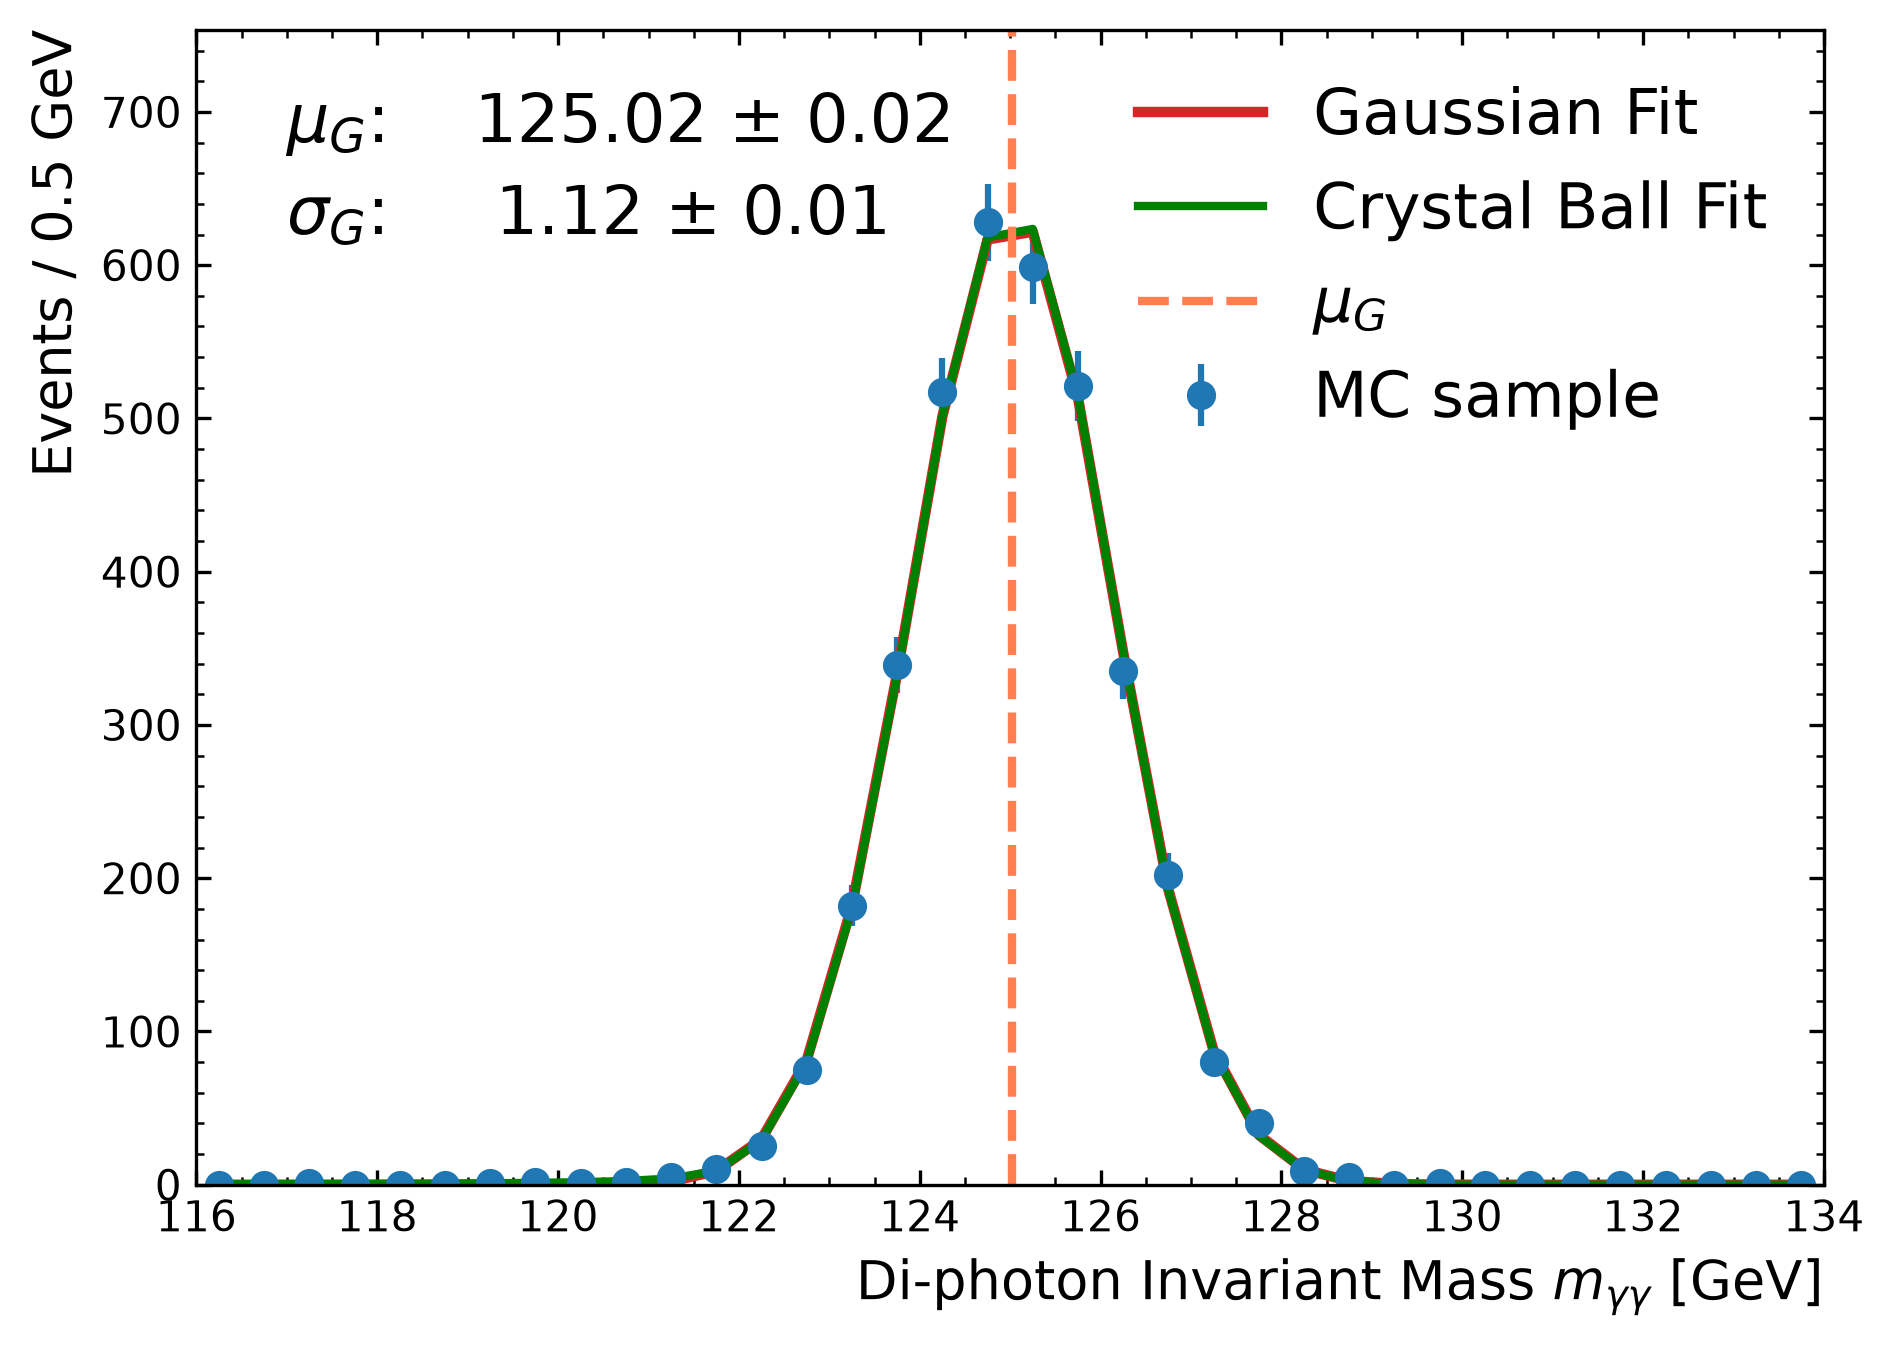

In [208]:
fit_color = '#d62728'  
cb_fit_color = 'green'

# plot
plt.figure(figsize=(7,5),dpi=300)
ax = plt.gca() # get current axes

# plot the data points
ax.errorbar(x=bincenters, y=data_x, yerr=data_x_errors,
                    fmt='o', # 'k' means black and 'o' is for circles
                    color='#1f77b4',
                    label=r'MC sample')

# plot fit
ax.plot(bincenters, fit.best_fit, '-', color=fit_color, label="Gaussian Fit", linewidth=2.5)
ax.plot(bincenters,fit_cb.best_fit,'-',color=cb_fit_color,label="Crystal Ball Fit",linewidth=2)

# set the x-limit of the main axes
ax.set_xlim( left=xmin, right=xmax )

ax.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
ax.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

ax.set_xlabel(r'Di-photon Invariant Mass $m_{\gamma\gamma}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )
ax.set_ylabel('Events / '+str(step_size)+' GeV', fontsize=13,
                        y=1, horizontalalignment='right')
ax.set_ylim( bottom=0, top=np.amax(data_x)*1.2 )
ax.yaxis.set_minor_locator( AutoMinorLocator() )

# draw the legend
plt.axvline(x=mu, linestyle='--', linewidth=2, color='coral',label=r'$\mu_G$')
plt.text(117,680,rf"$\mu_G$:    {mu:.2f} $\pm$ {mu_err:.2f}",fontsize=16)
plt.text(117,620,rf"$\sigma_G$:     {sigma:.2f} $\pm$ {sigma_err:.2f}",fontsize=16)

ax.legend( frameon=False,fontsize=15,loc='upper right' ) 
plt.savefig("plots/massspec_withfits_mc.png")


# Convert data from MG, Pythia, Delphes to histograms

In [186]:
# define bins
bins_pt = np.linspace(0, 100, 26)
bins_eta = np.linspace(-3, 3, 26)
bins_dphi = np.linspace(0, np.pi, 26)
bins_masses = np.linspace(110,140,36)

# madgraph events
mg_counts_lead, _ = np.histogram(mg_pts_lead, bins=bins_pt)
mg_counts_sub, _  = np.histogram(mg_pts_sub, bins=bins_pt)
mg_counts_eta, _  = np.histogram(mg_etas, bins=bins_eta)
mg_counts_dphi, _ = np.histogram(mg_dphis, bins=bins_dphi)
mg_counts_masses, _ = np.histogram(mg_masses, bins=bins_masses)
mg_err_masses = np.sqrt(mg_counts_masses)

# pythia events
py_counts_lead, _ = np.histogram(pythia_pts_lead, bins=bins_pt)
py_counts_sub, _  = np.histogram(pythia_pts_sub, bins=bins_pt)
py_counts_eta, _  = np.histogram(pythia_etas, bins=bins_eta)
py_counts_dphi, _ = np.histogram(pythia_dphis, bins=bins_dphi)
py_counts_masses, _ = np.histogram(pythia_masses, bins=bins_masses)
py_err_masses = np.sqrt(py_counts_masses)

# after cutflow
counts_lead, _ = np.histogram(pts_lead, bins=bins_pt)
counts_sub, _  = np.histogram(pts_sub, bins=bins_pt)
counts_eta, _  = np.histogram(etas, bins=bins_eta)
counts_dphi, _ = np.histogram(dphis, bins=bins_dphi)
counts_masses, _ = np.histogram(ak.to_numpy(masses_all), bins=bins_masses)
delphes_err_masses = np.sqrt(counts_masses)

/var/folders/1f/v2ws8crn4c34nx9fvpdjdb2c0000gn/T/ipykernel_37279/2099569245.py:50: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.tight_layout()
/var/folders/1f/v2ws8crn4c34nx9fvpdjdb2c0000gn/T/ipykernel_37279/2099569245.py:51: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig("plots/allsimstages_kinematics.png")
/Users/chris/intro-hep-project/day4_env_try2/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


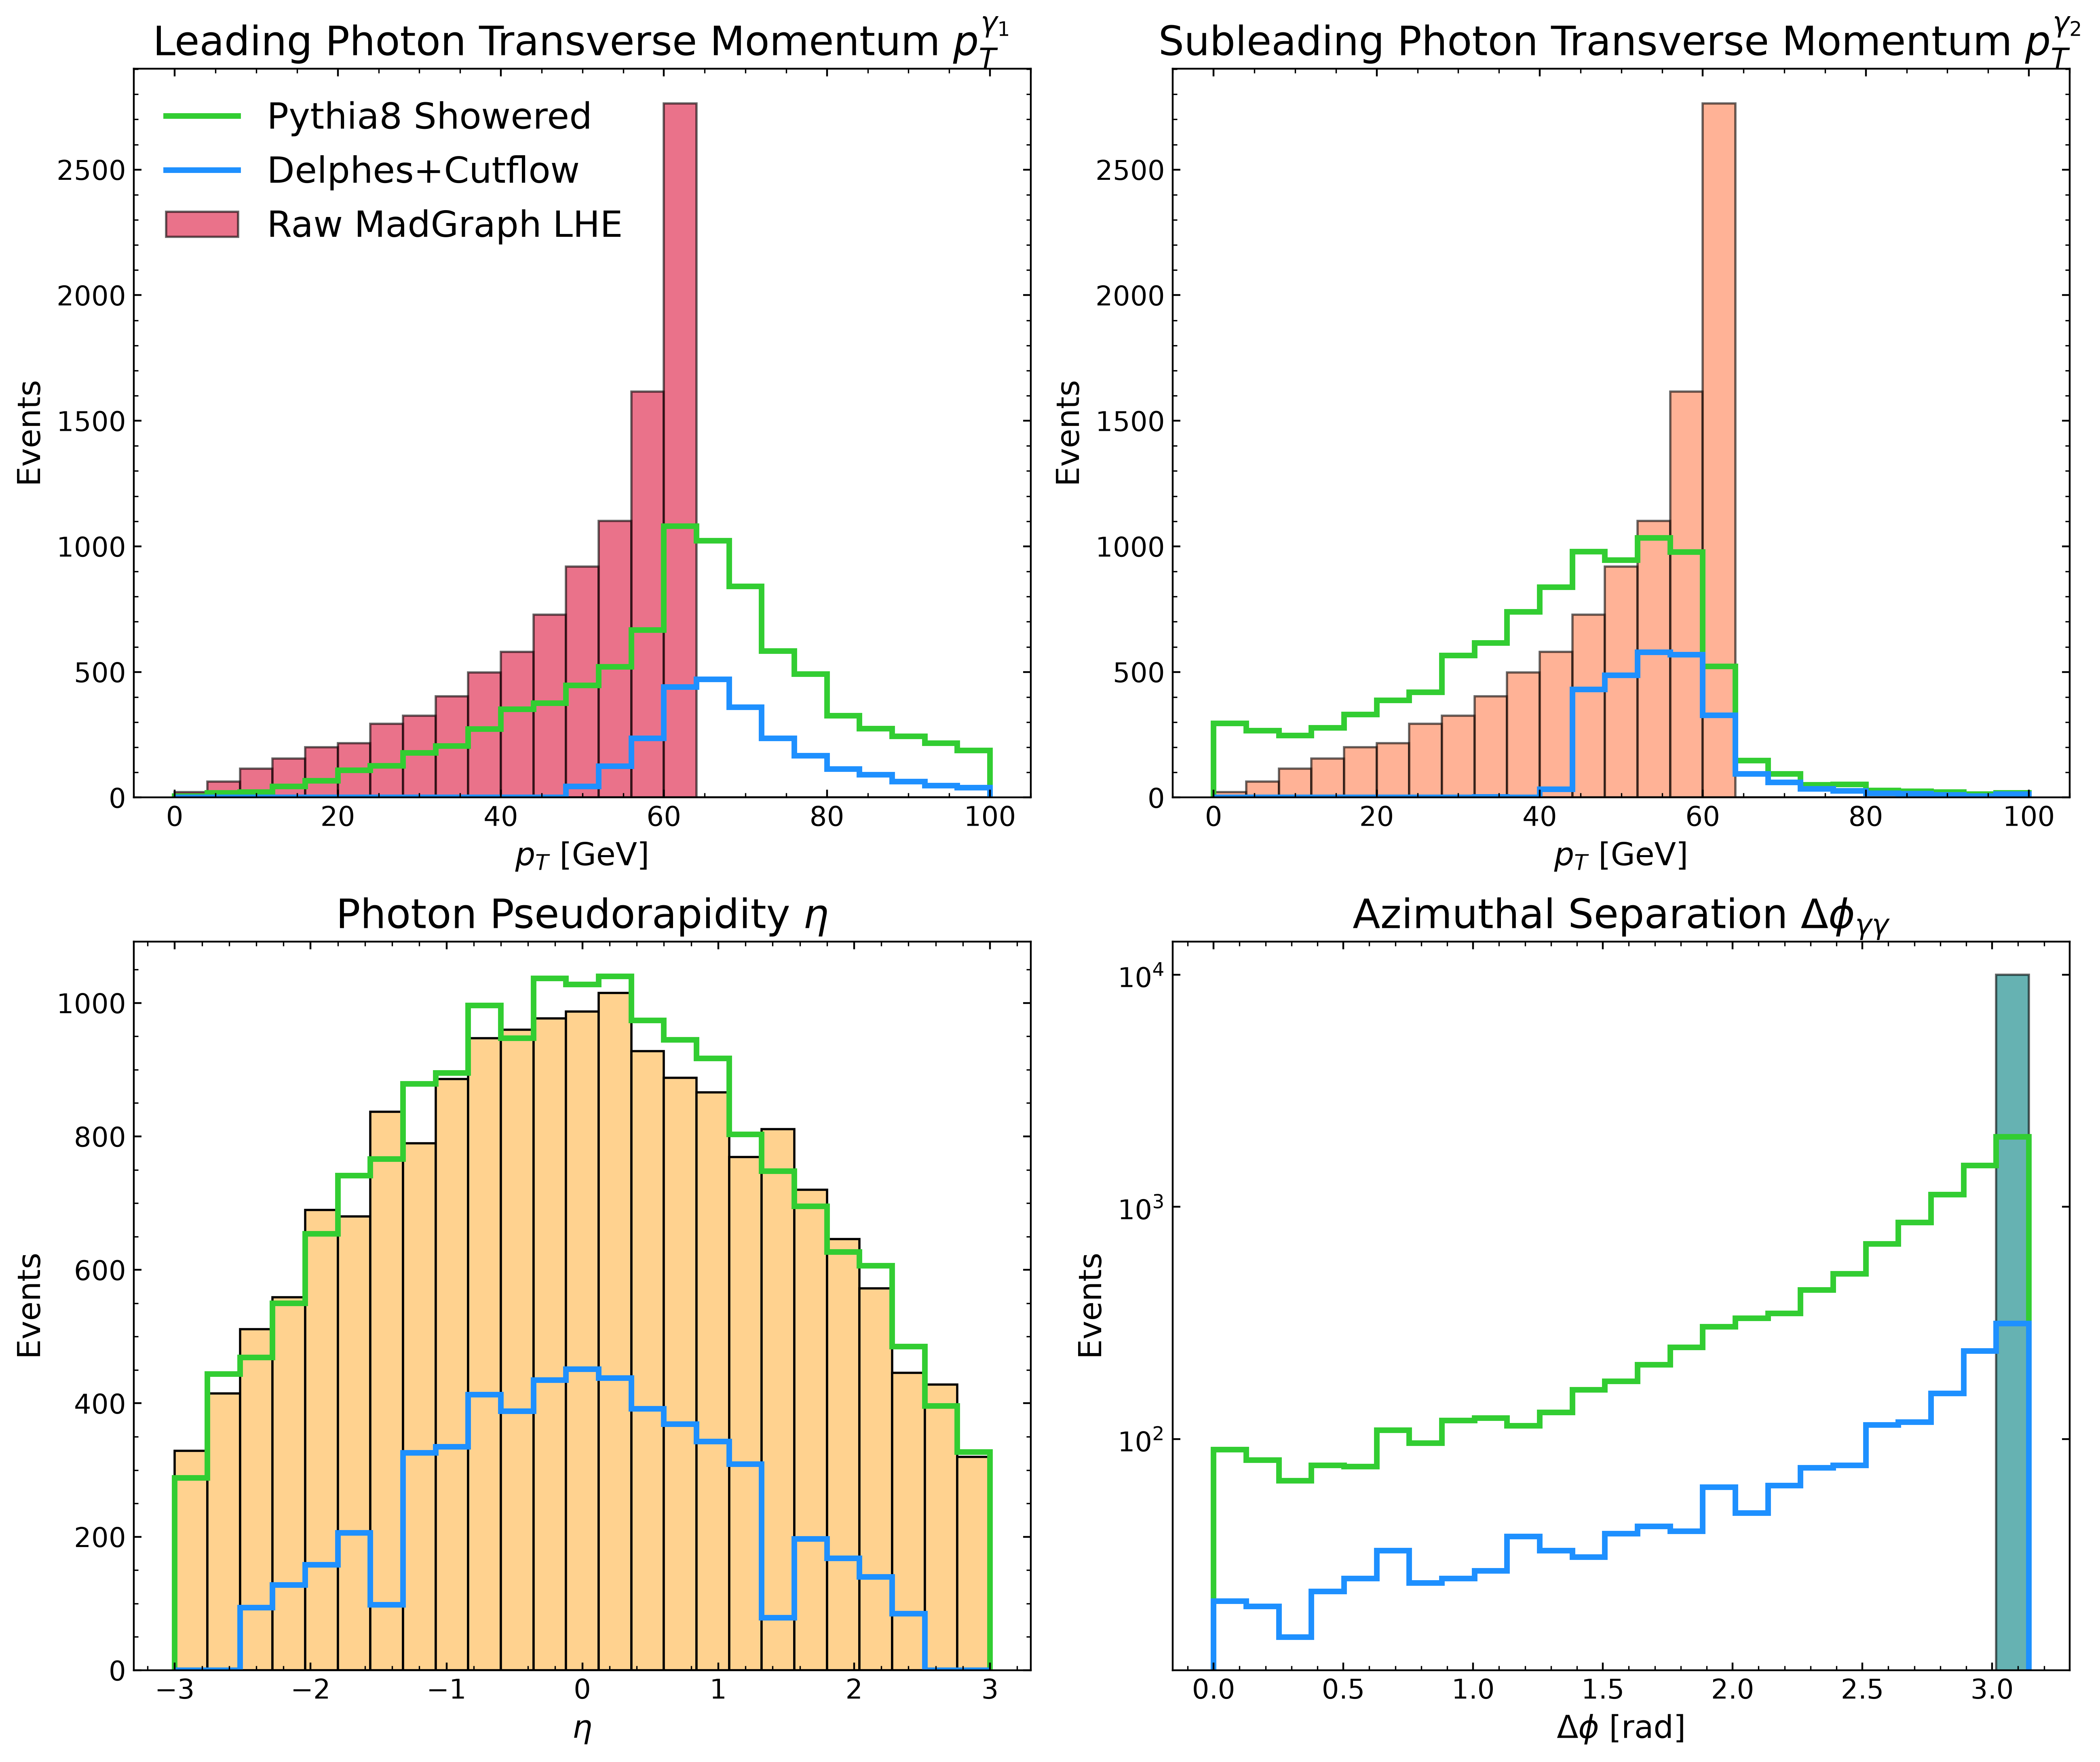

In [193]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11), dpi=400)

sunset_yellow = "#FCE38A"
apricot = "#FFD28F"

# --- 1. Leading Photon pT ---
axes[0, 0].bar(bins_pt[:-1], mg_counts_lead, width=np.diff(bins_pt), align="edge", 
               color="crimson", edgecolor="black", alpha=0.6, label="Raw MadGraph LHE")
axes[0, 0].stairs(py_counts_lead, bins_pt, color="limegreen", linewidth=2.5, label="Pythia8 Showered")
axes[0, 0].stairs(counts_lead, bins_pt, color="dodgerblue", linewidth=2.5, label="Delphes+Cutflow")
axes[0, 0].set_title(r'Leading Photon Transverse Momentum $p_T^{\gamma_1}$', fontsize=18)
axes[0, 0].set_xlabel(r'$p_T$ [GeV]', fontsize=14)

# Place the only legend here, slightly larger
axes[0, 0].legend(frameon=False, fontsize=16, loc='upper left')

# --- 2. Subleading Photon pT ---
axes[0, 1].bar(bins_pt[:-1], mg_counts_sub, width=np.diff(bins_pt), align="edge", 
               color="coral", edgecolor="black", alpha=0.6)
axes[0, 1].stairs(py_counts_sub, bins_pt, color="limegreen", linewidth=2.5)
axes[0, 1].stairs(counts_sub, bins_pt, color="dodgerblue", linewidth=2.5)
axes[0, 1].set_title(r'Subleading Photon Transverse Momentum $p_T^{\gamma_2}$', fontsize=18)
axes[0, 1].set_xlabel(r'$p_T$ [GeV]', fontsize=14)

# --- 3. Photon Eta (Sunset Pink) ---
axes[1, 0].bar(bins_eta[:-1], mg_counts_eta, width=np.diff(bins_eta), align="edge", 
               color=apricot, edgecolor="black", alpha=1)
axes[1, 0].stairs(py_counts_eta, bins_eta, color="limegreen", linewidth=2.5)
axes[1, 0].stairs(counts_eta, bins_eta, color="dodgerblue", linewidth=2.5)
axes[1, 0].set_title(r'Photon Pseudorapidity $\eta$', fontsize=18)
axes[1, 0].set_xlabel(r'$\eta$', fontsize=14)

# --- 4. Delta Phi ---
axes[1, 1].bar(bins_dphi[:-1], mg_counts_dphi, width=np.diff(bins_dphi), align="edge", 
               color="teal", edgecolor="black", alpha=0.6)
axes[1, 1].stairs(py_counts_dphi, bins_dphi, color="limegreen", linewidth=2.5)
axes[1, 1].stairs(counts_dphi, bins_dphi, color="dodgerblue", linewidth=2.5)
axes[1, 1].set_title(r'Azimuthal Separation $\Delta\phi_{\gamma\gamma}$', fontsize=18)
axes[1, 1].set_xlabel(r'$\Delta\phi$ [rad]', fontsize=14)
axes[1, 1].set_yscale('log')

# --- Common Formatting ---
for ax in axes.flat:
    ax.set_ylabel('Events', fontsize=14)
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

#fig.suptitle("Signal Event Kinematics across Simulation Stages", fontsize=20, y=0.98)
plt.tight_layout()
plt.savefig("plots/allsimstages_kinematics.png")

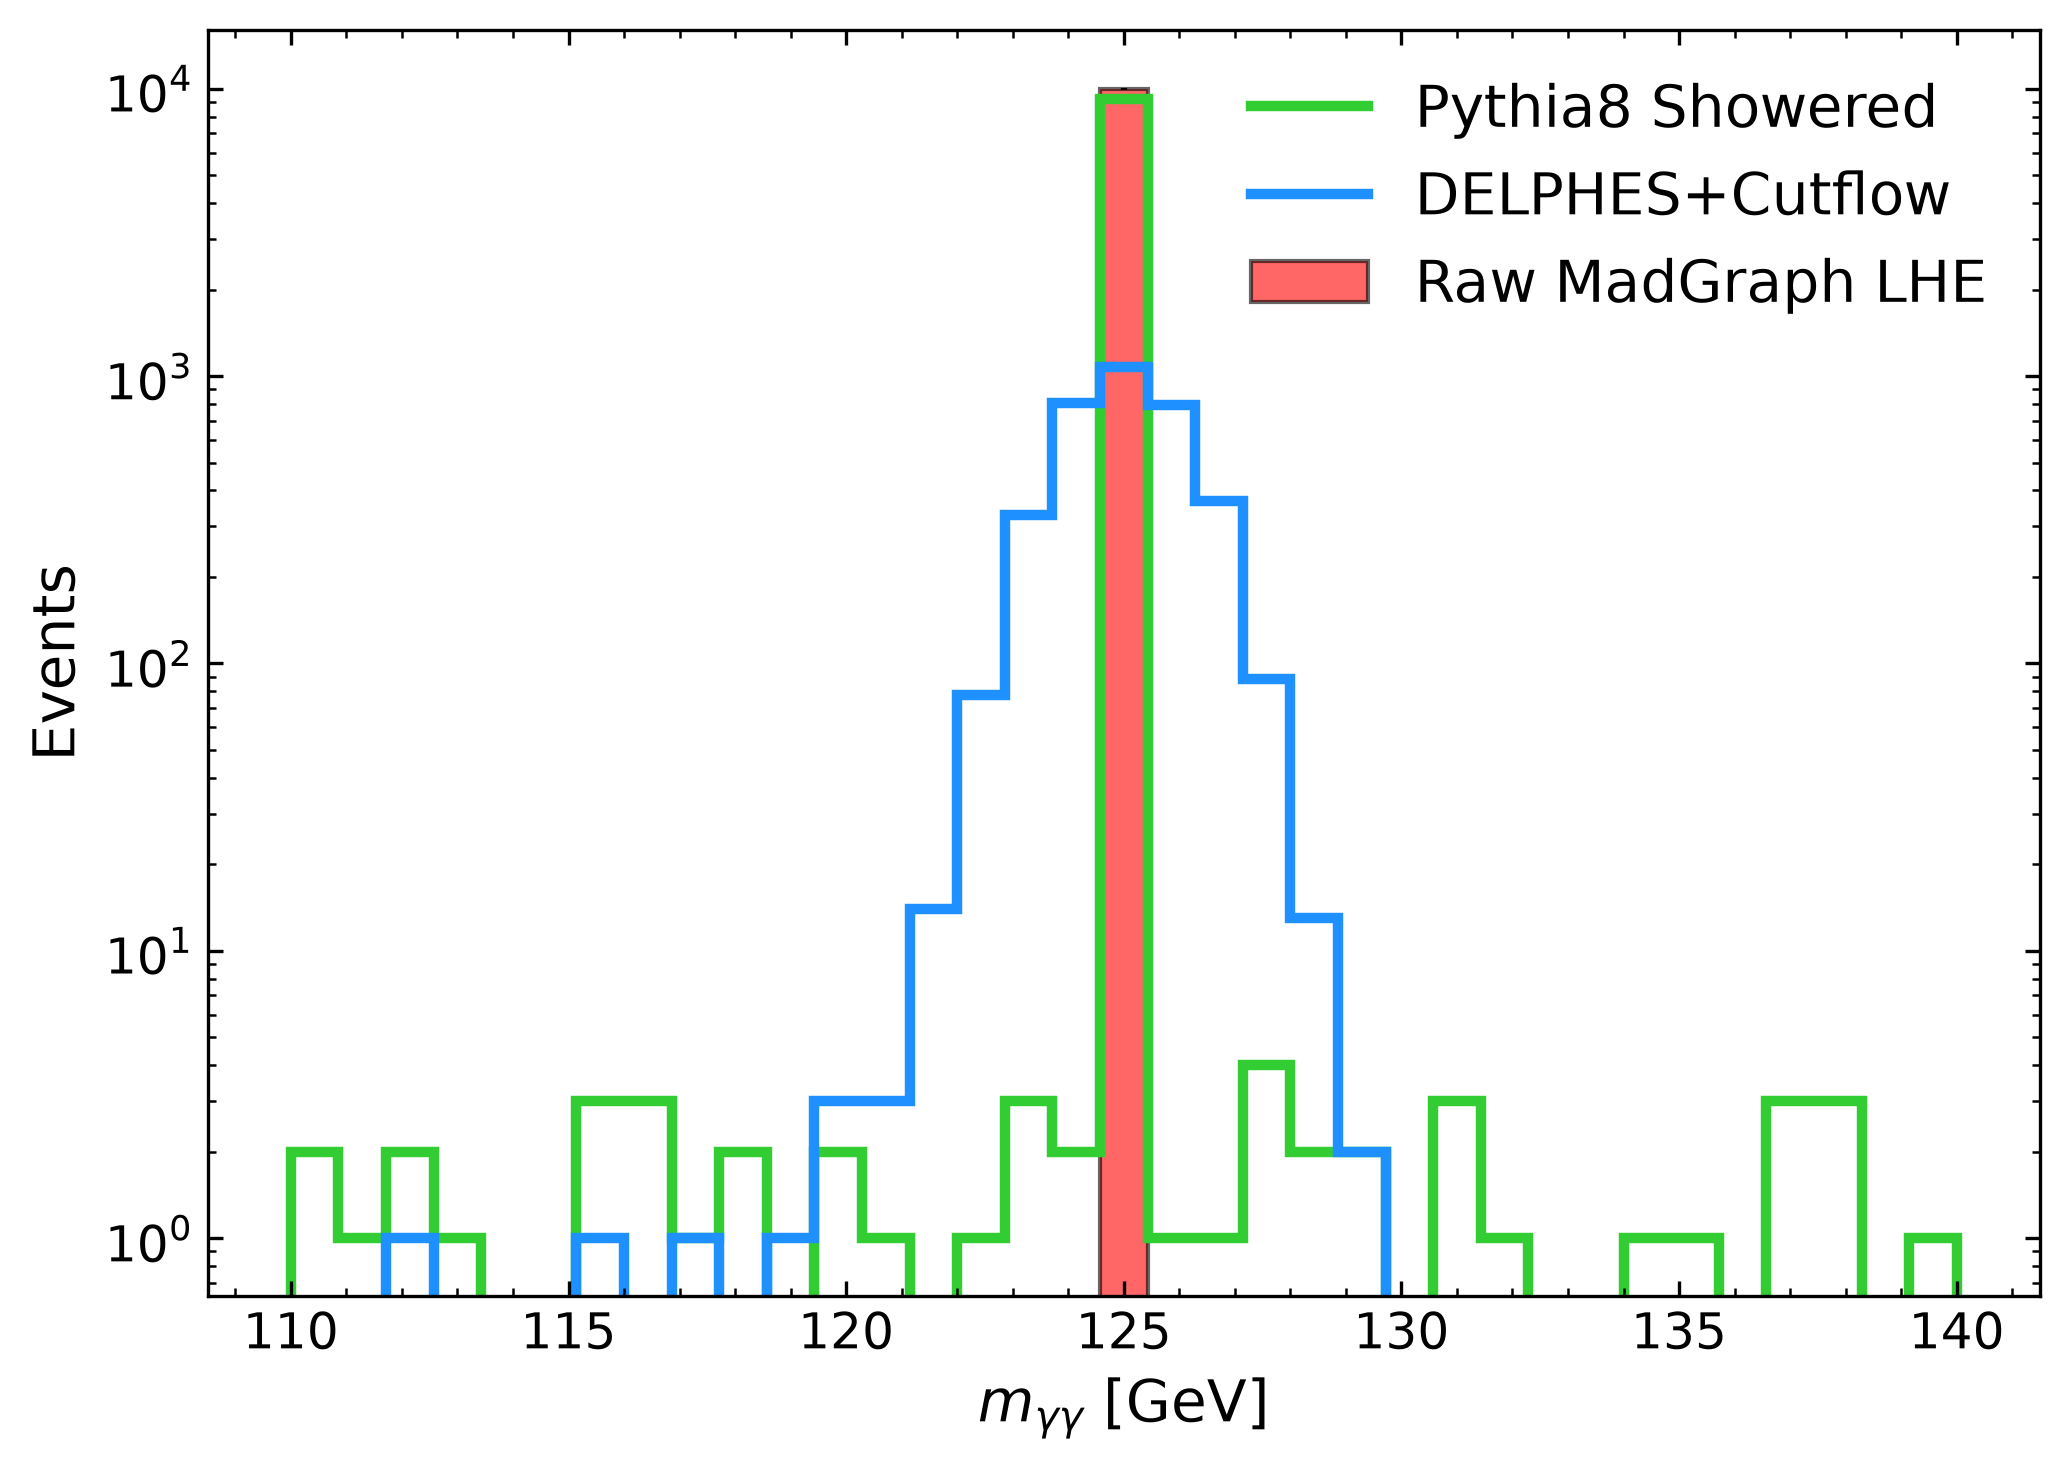

In [187]:
plt.figure(figsize=(7,5),dpi=300)
axes = plt.gca()

axes.bar(bins_masses[:-1], mg_counts_masses, width=np.diff(bins_masses), align="edge", 
         yerr=mg_err_masses,color="red", edgecolor="black", alpha=0.6, label="Raw MadGraph LHE")
axes.stairs(py_counts_masses, bins_masses, color="limegreen", linewidth=2.5, label="Pythia8 Showered")
axes.stairs(counts_masses, bins_masses, color="dodgerblue", linewidth=2.5, label="DELPHES+Cutflow")
#axes.set_title(r'Invariant Mass Spectrum Across Sim Stages', fontsize=16)
axes.set_xlabel(r'$m_{\gamma\gamma}$ [GeV]', fontsize=14)
axes.set_yscale('log')


axes.set_ylabel('Events', fontsize=14)
axes.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
axes.xaxis.set_minor_locator(AutoMinorLocator())

plt.legend(fontsize=14,frameon=False)
plt.tight_layout()
plt.savefig("plots/allsimstage_mass.png")

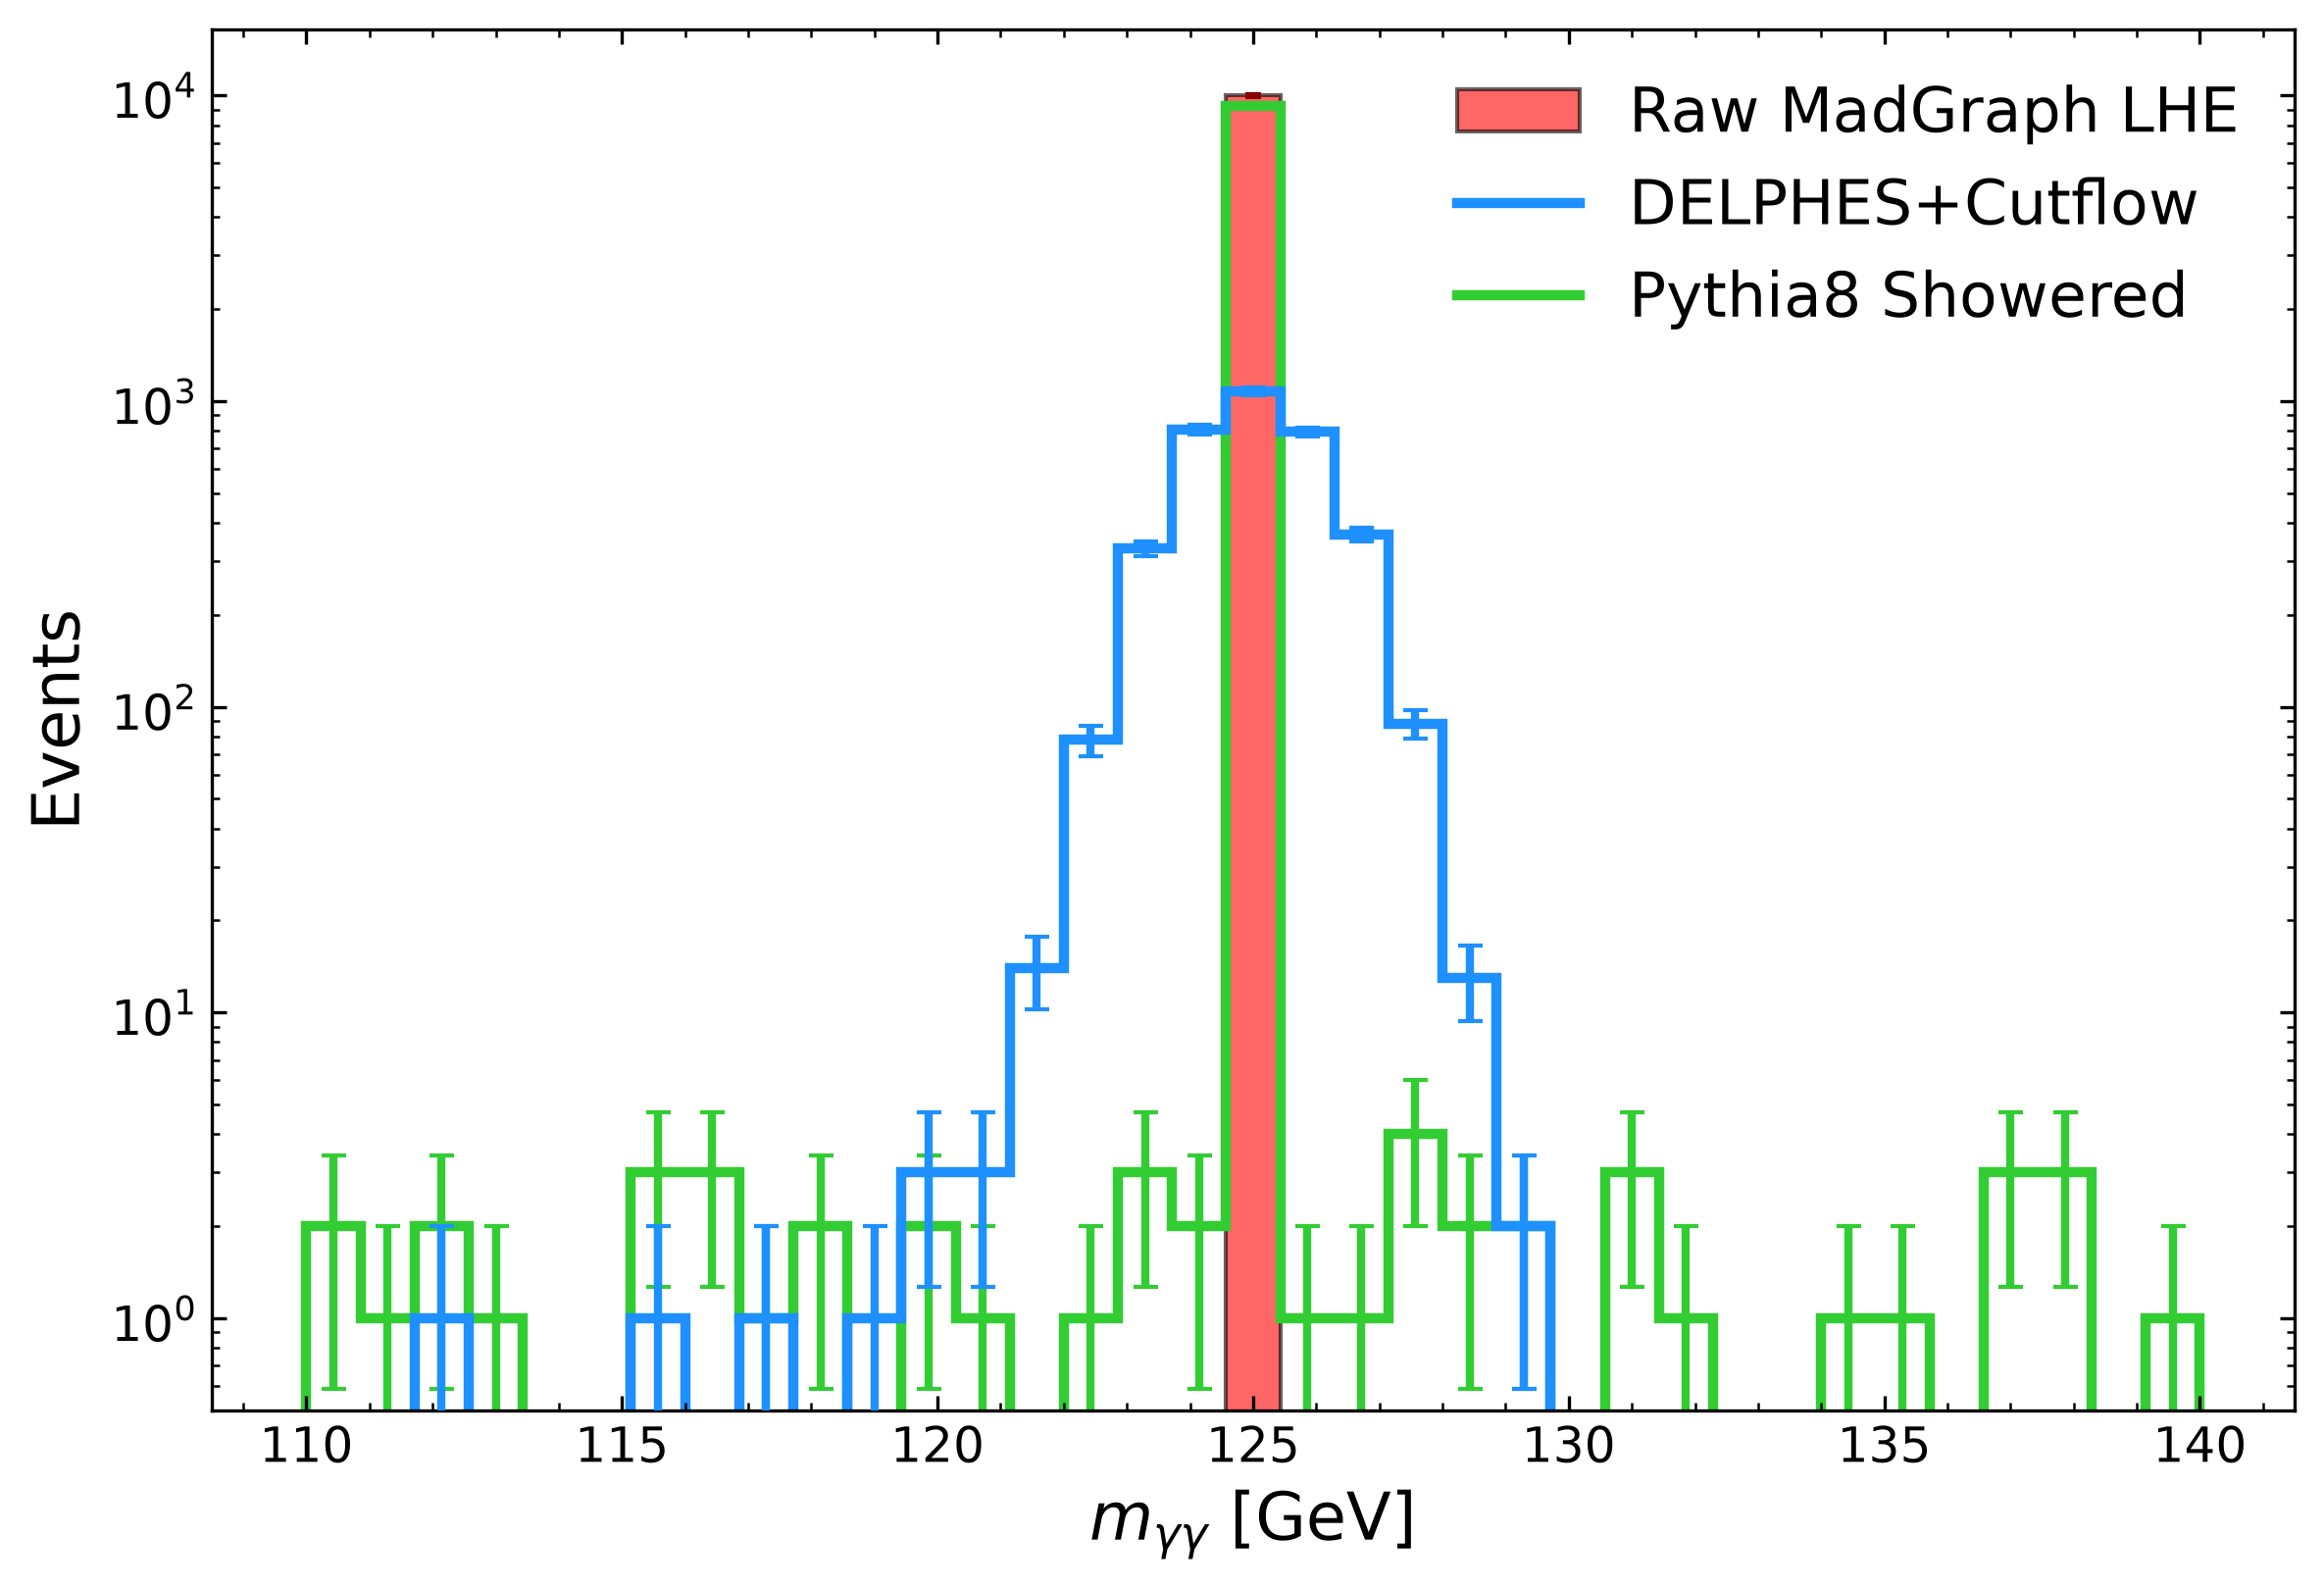

In [192]:
bin_centers_masses = (bins_masses[:-1] + bins_masses[1:]) / 2

plt.figure(figsize=(8, 5.5), dpi=300)
axes = plt.gca()

# 1. Raw MadGraph LHE
axes.bar(bins_masses[:-1], mg_counts_masses, width=np.diff(bins_masses), align="edge", 
         yerr=mg_err_masses, color="red", edgecolor="black", alpha=0.6, 
         label="Raw MadGraph LHE", ecolor="darkred", capsize=2)

# 2. Pythia8 Showered
axes.stairs(py_counts_masses, bins_masses, color="limegreen", linewidth=2.5, label="Pythia8 Showered")
axes.errorbar(bin_centers_masses, py_counts_masses, yerr=py_err_masses, fmt="none", 
              ecolor="limegreen", elinewidth=2, capsize=3, zorder=2)

# 3. DELPHES+Cutflow
axes.stairs(counts_masses, bins_masses, color="dodgerblue", linewidth=2.5, label="DELPHES+Cutflow")
axes.errorbar(bin_centers_masses, counts_masses, yerr=delphes_err_masses, fmt="none", 
              ecolor="dodgerblue", elinewidth=2, capsize=3, zorder=3)

# Formatting
axes.set_yscale('log')
axes.set_ylim(bottom=0.5)
axes.set_xlabel(r'$m_{\gamma\gamma}$ [GeV]', fontsize=16)
axes.set_ylabel('Events', fontsize=16)
axes.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
axes.xaxis.set_minor_locator(AutoMinorLocator())

# Reversed legend order
handles, labels = axes.get_legend_handles_labels()
axes.legend(handles[::-1], labels[::-1], fontsize=15, frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("plots/allsimstage_mass.png")

In [131]:
# export the data to read into the Hgg_analysis notebook (for side by side data vs. MC plots)
np.savez(
    "histogram_data.npz",
    pts_lead=pts_lead,
    pts_sub=pts_sub,
    pts_digam=pts_digam,
    dphis=dphis,
)

In [132]:
# define bins for each of these histo
bins_h1and2 = np.linspace(0,100,41)
bins_h3 = np.linspace(0,300,41)
bins_h4 = np.linspace(0,np.pi,41)

# histogram sideband
counts_higgs_pts_lead , edges1 = np.histogram(pts_lead ,bins=bins_h1and2)
counts_higgs_pts_sub  , edges2 = np.histogram(pts_sub  ,bins=bins_h1and2)
counts_higgs_pts_digam, edges3 = np.histogram(pts_digam,bins=bins_h3)
counts_higgs_dphis    , edges4 = np.histogram(dphis    ,bins=bins_h4)

err_lead  = np.sqrt(counts_higgs_pts_lead)
err_sub   = np.sqrt(counts_higgs_pts_sub )
err_digam = np.sqrt(counts_higgs_pts_digam)
err_dphi  = np.sqrt(counts_higgs_dphis   )

# do normalization for each plot
# total area under histogram = sum(y_i * dx) = sum(y_i) * dx
norm_lead  = np.abs(np.sum(counts_higgs_pts_lead) * (bins_h1and2[1] - bins_h1and2[2]))
norm_sub   = np.abs(np.sum(counts_higgs_pts_sub)  * (bins_h1and2[1] - bins_h1and2[2]))
norm_digam = np.abs(np.sum(counts_higgs_pts_digam)* (bins_h3[1] - bins_h3[2]))
norm_dphi  = np.abs(np.sum(counts_higgs_dphis)   * (bins_h4[1] - bins_h4[2]))

counts_higgs_pts_lead  = counts_higgs_pts_lead  / norm_lead 
counts_higgs_pts_sub   = counts_higgs_pts_sub   / norm_sub  
counts_higgs_pts_digam = counts_higgs_pts_digam / norm_digam
counts_higgs_dphis     = counts_higgs_dphis     / norm_dphi 

err_lead  =  err_lead / norm_lead 
err_sub   = err_sub   / norm_sub  
err_digam = err_digam / norm_digam
err_dphi  = err_dphi  / norm_dphi 

# convert to numpy arrays for print statements

counts_higgs_pts_lead  = ak.to_numpy(counts_higgs_pts_lead )
counts_higgs_pts_sub   = ak.to_numpy(counts_higgs_pts_sub  )
counts_higgs_pts_digam = ak.to_numpy(counts_higgs_pts_digam)
counts_higgs_dphis     = ak.to_numpy(counts_higgs_dphis    )

err_lead  = ak.to_numpy(err_lead )
err_sub   = ak.to_numpy(err_sub  )
err_digam = ak.to_numpy(err_digam)
err_dphi  = ak.to_numpy(err_dphi )

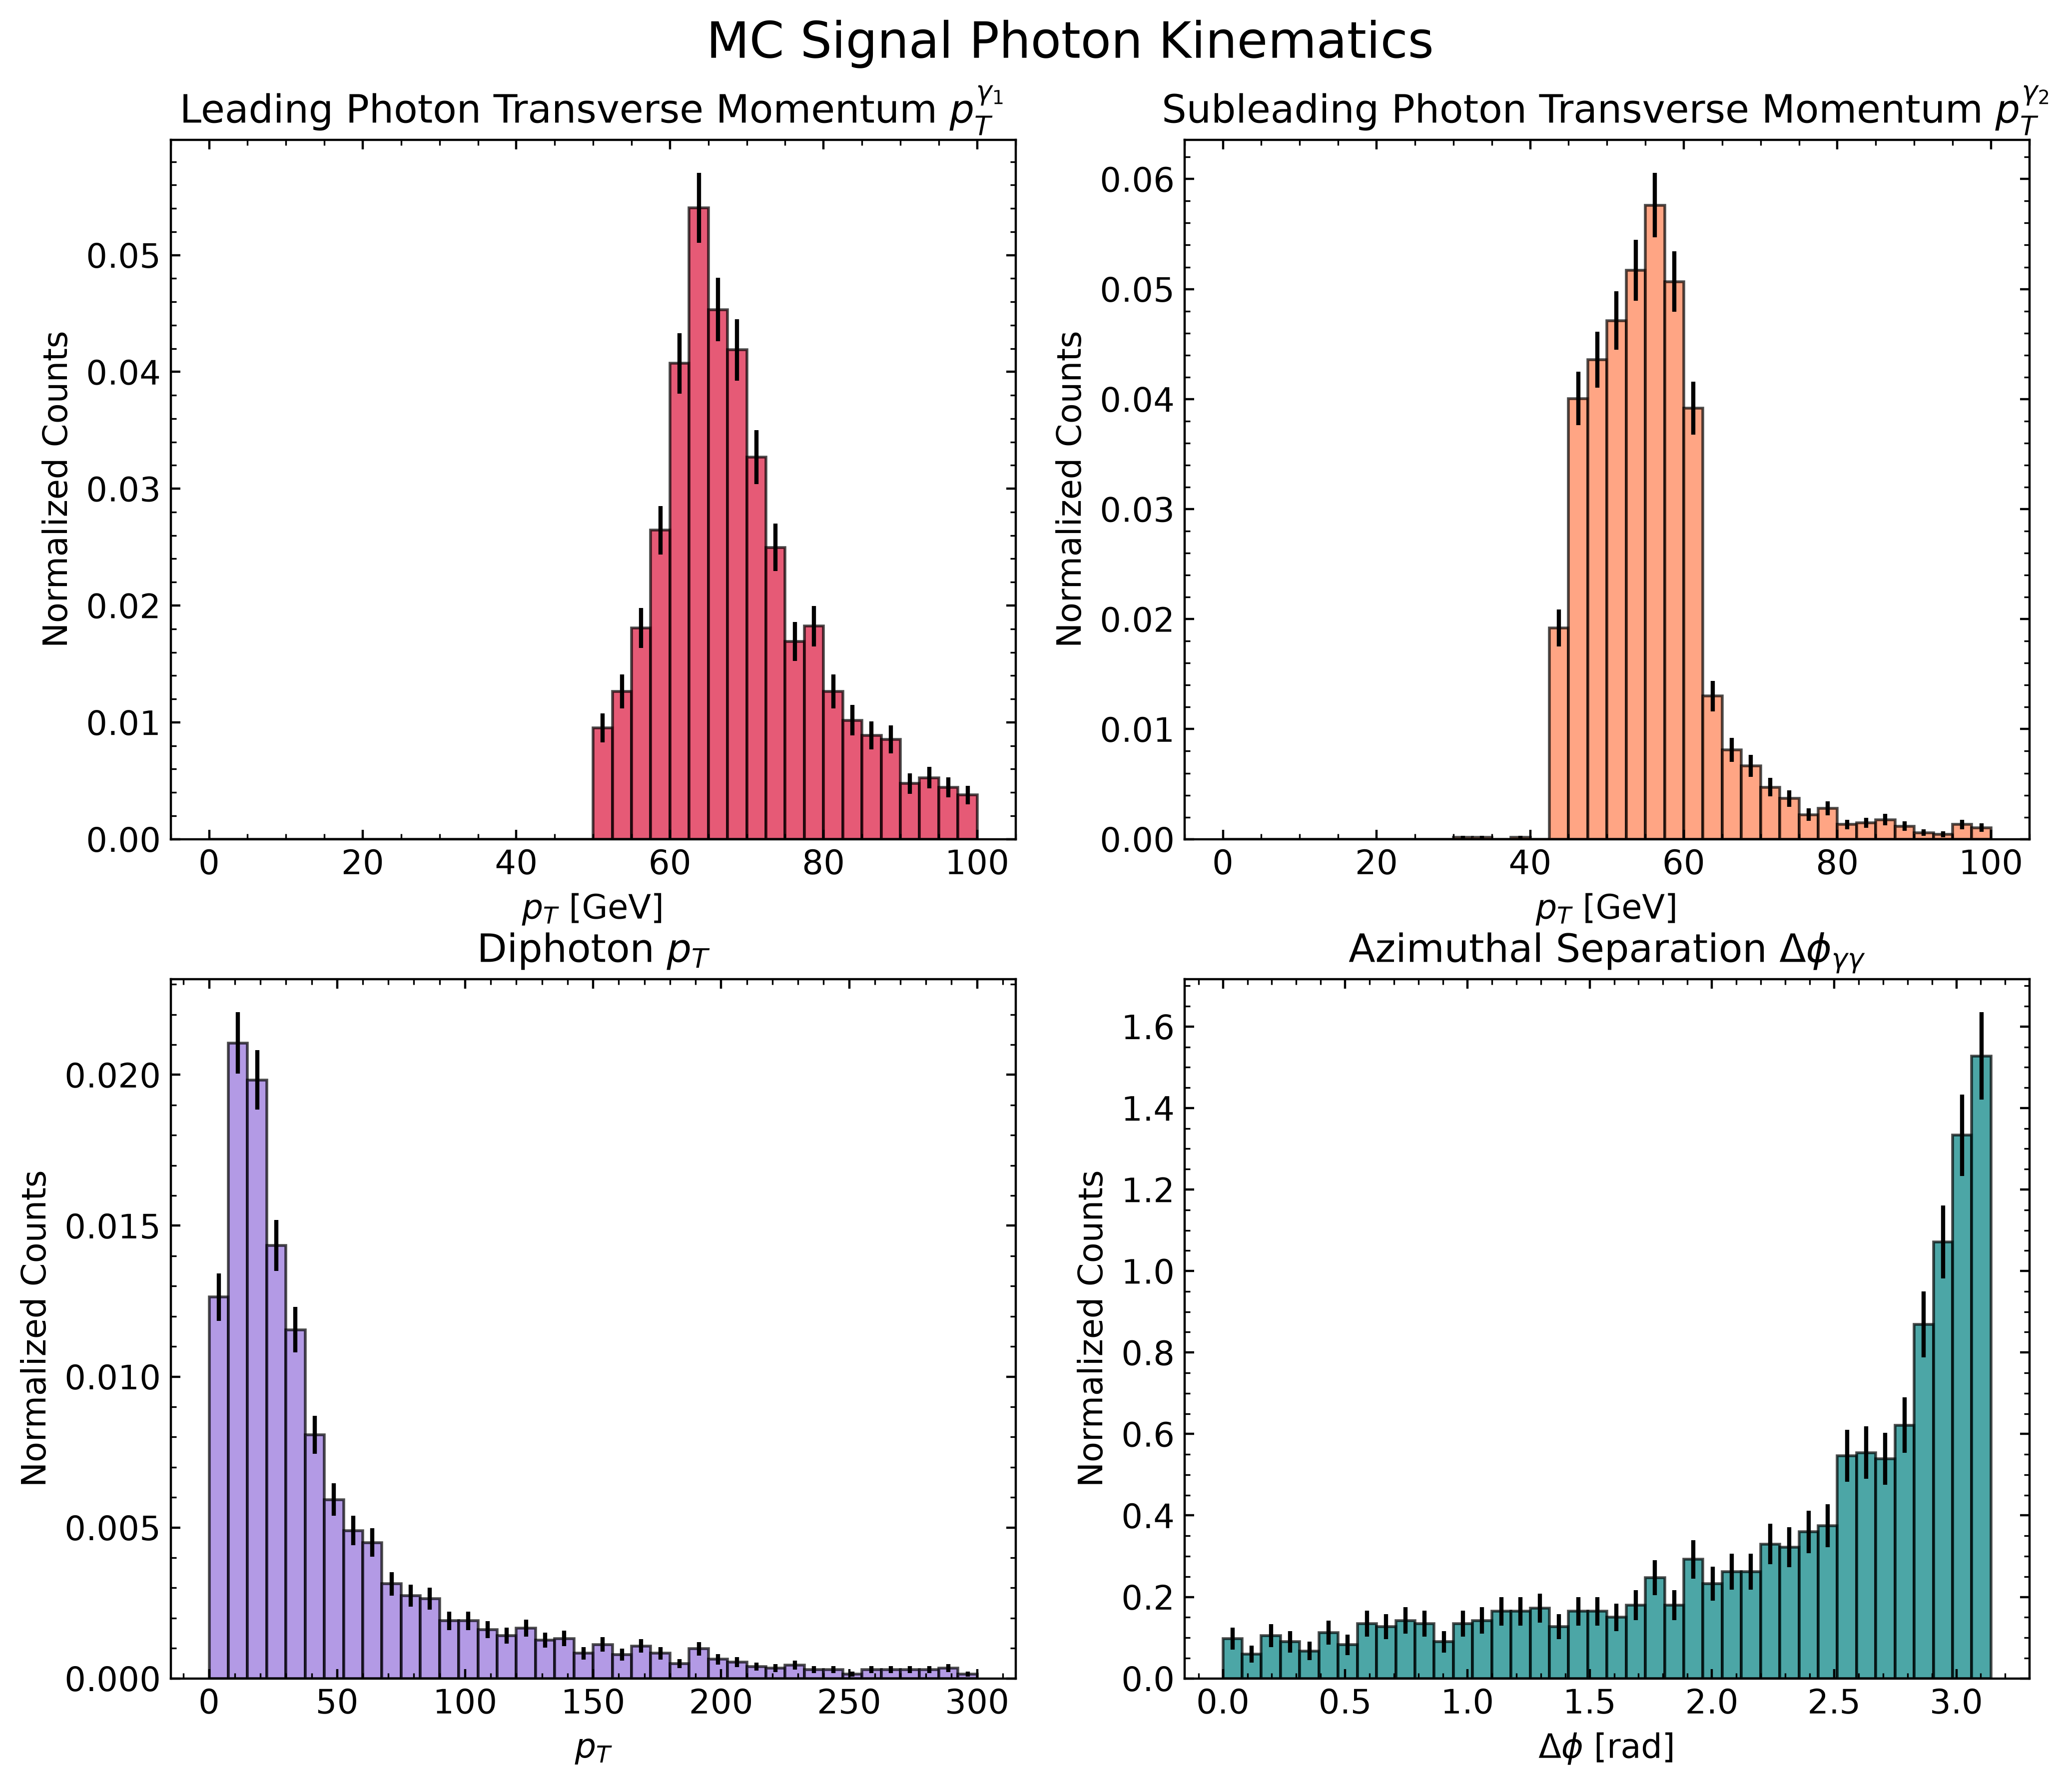

In [124]:
fig, axes = plt.subplots(2,2,figsize=(12,10),dpi=400)

# 1. Leading Photon pT
axes[0, 0].bar(edges1[:-1],counts_higgs_pts_lead, width=np.diff(edges1), yerr=err_lead,
        align="edge",color="crimson",edgecolor="black",alpha=0.7)
axes[0, 0].set_title(r'Leading Photon Transverse Momentum $p_T^{\gamma_1}$',fontsize=14)
axes[0, 0].set_xlabel(r'$p_T$ [GeV]',fontsize=12)
axes[0, 0].set_ylabel('Normalized Counts',fontsize=12)

# 2. Subleading Photon pT
axes[0, 1].bar(edges2[:-1],counts_higgs_pts_sub, width=np.diff(edges2), yerr=err_sub,
        align="edge",color="coral",edgecolor="black",alpha=0.7)
axes[0, 1].set_title(r'Subleading Photon Transverse Momentum $p_T^{\gamma_2}$',fontsize=14)
axes[0, 1].set_xlabel(r'$p_T$ [GeV]',fontsize=12)
axes[0, 1].set_ylabel('Normalized Counts',fontsize=12)

# 3. digam pT
axes[1, 0].bar(edges3[:-1],counts_higgs_pts_digam, width=np.diff(edges3), yerr=err_digam,
        align="edge",color="mediumpurple",edgecolor="black",alpha=0.7)
axes[1, 0].set_title(r'Diphoton $p_T$',fontsize=14)
axes[1, 0].set_xlabel(r'$p_T$',fontsize=12)
axes[1, 0].set_ylabel('Normalized Counts',fontsize=12)

# 4. Delta Phi
axes[1, 1].bar(edges4[:-1],counts_higgs_dphis, width=np.diff(edges4), yerr=err_dphi,
        align="edge",color="teal",edgecolor="black",alpha=0.7)
axes[1, 1].set_title(r'Azimuthal Separation $\Delta\phi_{\gamma\gamma}$',fontsize=14)
axes[1, 1].set_xlabel(r'$\Delta\phi$ [rad]',fontsize=12)
axes[1, 1].set_ylabel('Normalized Counts',fontsize=12)

axes[0,0].tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
axes[0,1].tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
axes[1,0].tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
axes[1,1].tick_params(which='both', direction='in', top=True, right=True, labelsize=12)

axes[0,0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0,0].yaxis.set_minor_locator(AutoMinorLocator())

axes[1,0].xaxis.set_minor_locator(AutoMinorLocator())
axes[1,0].yaxis.set_minor_locator(AutoMinorLocator())

axes[0,1].xaxis.set_minor_locator(AutoMinorLocator())
axes[0,1].yaxis.set_minor_locator(AutoMinorLocator())

axes[1,1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1,1].yaxis.set_minor_locator(AutoMinorLocator())


fig.suptitle("MC Signal Photon Kinematics",fontsize=18,y=0.94)
plt.savefig('plots/mc_sig_photonkin_afteranalysis.png')
